In [26]:
import h5py
import numpy as np

file_path = '/scratch/nar8991/snn/snn_ann_hybrid/maren_data/shd/700_inputs/1.0_max_time/False_noise/cache_0.002/test/0_0.hdf5'

data_array = None
target_array = None

with h5py.File(file_path, 'r') as f:
    
    # 1. Load the Data Array (assuming the nested structure is correct from before)
    data_subkey = list(f['data'].keys())[0] 
    data_array = f['data'][data_subkey][:] 
    print(f"✅ Loaded data from /data/{data_subkey}. Shape: {data_array.shape}")

    print("-" * 40)
    
    # 2. Load the Target Array (The FINAL FIX for the scalar dataspace error)
    if isinstance(f['target'], h5py.Group):
        target_subkey = list(f['target'].keys())[0] 
        target_dataset = f['target'][target_subkey]

        # Check if it's a scalar dataset before trying to slice it
        if target_dataset.shape == ():
            # Use the correct empty-tuple slicing for scalar data
            target_array = target_dataset[()]
            print(f"✅ Loaded scalar target from /target/{target_subkey}.")
            # Note: A scalar [()] returns a NumPy array-scalar, so its shape is ()
        else:
            # If it's a regular array, use the standard slice
            target_array = target_dataset[:]
            print(f"✅ Loaded array target from /target/{target_subkey}.")
        
        print(f"Shape of the target array: {target_array.shape}, Value: {target_array}")
    
    else:
        # Fallback in case 'target' was a top-level dataset (unlikely now)
        target_array = f['target'][()] if f['target'].shape == () else f['target'][:]


print("\n🎉 ALL DATA LOADED SUCCESSFULLY 🎉")
print(f"Final Data Array Shape: {data_array.shape}")
print(f"Final Target Array Shape: {target_array.shape}")

✅ Loaded data from /data/0. Shape: (366, 700)
----------------------------------------
✅ Loaded scalar target from /target/0.
Shape of the target array: (), Value: 10

🎉 ALL DATA LOADED SUCCESSFULLY 🎉
Final Data Array Shape: (366, 700)
Final Target Array Shape: ()


In [29]:
data_array.shape

(366, 700)

In [27]:
target_array

10

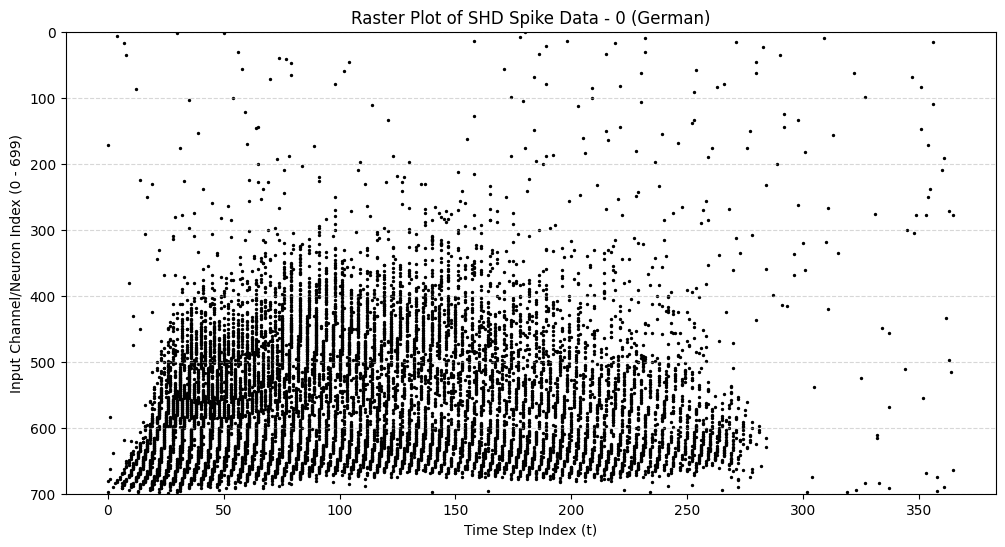

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the parameters based on the SHD dataset structure ---
# SHD has 700 input channels (neurons).
NUM_CHANNELS = 700 
# We'll assume one sample spans 700 channels across some number of time steps.
# Since your data_array shape is (366, 700), we'll assume the 366 are time steps
# for a single concatenated sample (or a single sample is much smaller). 
# We'll plot the entire (366, 700) array as one large sample for demonstration.

# --- 2. Extract and Prepare the Data ---
# Assuming 'data_array' (shape: N x 700) is already loaded from hdf5
# Example Dummy data generation (Replace this with your actual loaded data_array)
# data_array = np.random.randint(0, 2, size=(366, 700)) 
# data_array[data_array < 0.9] = 0 # Ensure it's mostly zeros

# Find the coordinates of the spikes (non-zero entries)
# 'spike_times' will hold the row index (Time) of the spike
# 'spike_channels' will hold the column index (Channel/Neuron) of the spike
spike_times, spike_channels = np.where(data_array > 0)

# --- 3. Create the Raster Plot ---
plt.figure(figsize=(12, 6))

# Use plt.scatter or plt.plot with markers for a classic raster plot
plt.scatter(
    spike_times,         # X-axis: Time (row index)
    spike_channels,      # Y-axis: Neuron/Channel (column index)
    s=2,                 # Marker size (adjust for visibility)
    color='black'
)

plt.xlabel("Time Step Index (t)")
plt.ylabel(f"Input Channel/Neuron Index (0 - {NUM_CHANNELS-1})")
plt.title("Raster Plot of SHD Spike Data - 0 (German)")
plt.ylim(0, NUM_CHANNELS) # Set Y-axis to cover all channels
plt.grid(True, axis='y', alpha=0.5, linestyle='--')
plt.gca().invert_yaxis() # Often done for raster plots to match the matrix view

plt.show()

In [37]:
import h5py
import numpy as np

file_path = '/scratch/nar8991/snn/snn_ann_hybrid/maren_data/shd/700_inputs/1.0_max_time/False_noise/cache_0.002/test/1_0.hdf5'

data_array = None
target_array = None

with h5py.File(file_path, 'r') as f:
    
    # 1. Load the Data Array (assuming the nested structure is correct from before)
    data_subkey = list(f['data'].keys())[0] 
    data_array = f['data'][data_subkey][:] 
    print(f"✅ Loaded data from /data/{data_subkey}. Shape: {data_array.shape}")

    print("-" * 40)
    
    # 2. Load the Target Array (The FINAL FIX for the scalar dataspace error)
    if isinstance(f['target'], h5py.Group):
        target_subkey = list(f['target'].keys())[0] 
        target_dataset = f['target'][target_subkey]

        # Check if it's a scalar dataset before trying to slice it
        if target_dataset.shape == ():
            # Use the correct empty-tuple slicing for scalar data
            target_array = target_dataset[()]
            print(f"✅ Loaded scalar target from /target/{target_subkey}.")
            # Note: A scalar [()] returns a NumPy array-scalar, so its shape is ()
        else:
            # If it's a regular array, use the standard slice
            target_array = target_dataset[:]
            print(f"✅ Loaded array target from /target/{target_subkey}.")
        
        print(f"Shape of the target array: {target_array.shape}, Value: {target_array}")
    
    else:
        # Fallback in case 'target' was a top-level dataset (unlikely now)
        target_array = f['target'][()] if f['target'].shape == () else f['target'][:]


print("\n🎉 ALL DATA LOADED SUCCESSFULLY 🎉")
print(f"Final Data Array Shape: {data_array.shape}")
print(f"Final Target Array Shape: {target_array.shape}")

✅ Loaded data from /data/0. Shape: (393, 700)
----------------------------------------
✅ Loaded scalar target from /target/0.
Shape of the target array: (), Value: 11

🎉 ALL DATA LOADED SUCCESSFULLY 🎉
Final Data Array Shape: (393, 700)
Final Target Array Shape: ()


In [39]:
target_array

11

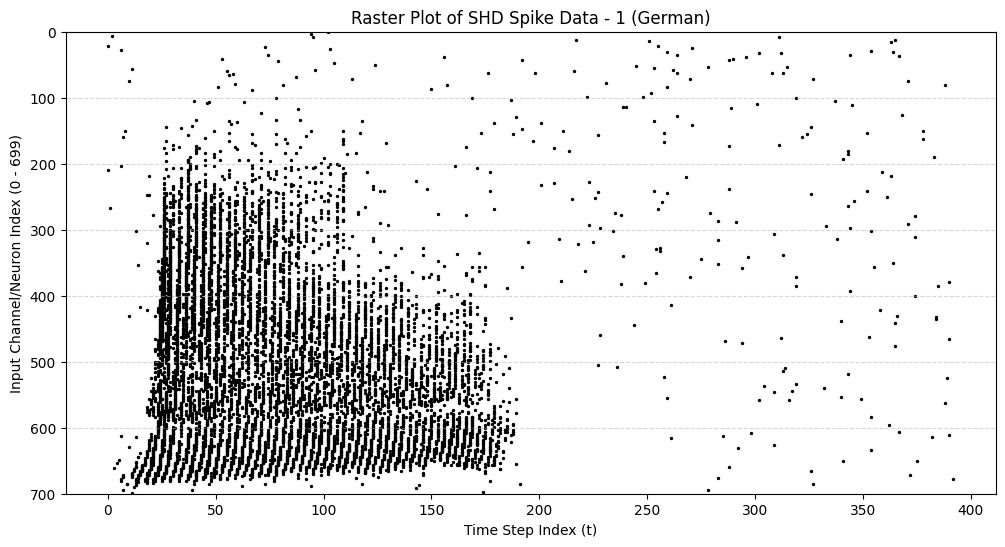

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the parameters based on the SHD dataset structure ---
# SHD has 700 input channels (neurons).
NUM_CHANNELS = 700 
# We'll assume one sample spans 700 channels across some number of time steps.
# Since your data_array shape is (366, 700), we'll assume the 366 are time steps
# for a single concatenated sample (or a single sample is much smaller). 
# We'll plot the entire (366, 700) array as one large sample for demonstration.

# --- 2. Extract and Prepare the Data ---
# Assuming 'data_array' (shape: N x 700) is already loaded from hdf5
# Example Dummy data generation (Replace this with your actual loaded data_array)
# data_array = np.random.randint(0, 2, size=(366, 700)) 
# data_array[data_array < 0.9] = 0 # Ensure it's mostly zeros

# Find the coordinates of the spikes (non-zero entries)
# 'spike_times' will hold the row index (Time) of the spike
# 'spike_channels' will hold the column index (Channel/Neuron) of the spike
spike_times, spike_channels = np.where(data_array > 0)

# --- 3. Create the Raster Plot ---
plt.figure(figsize=(12, 6))

# Use plt.scatter or plt.plot with markers for a classic raster plot
plt.scatter(
    spike_times,         # X-axis: Time (row index)
    spike_channels,      # Y-axis: Neuron/Channel (column index)
    s=2,                 # Marker size (adjust for visibility)
    color='black'
)

plt.xlabel("Time Step Index (t)")
plt.ylabel(f"Input Channel/Neuron Index (0 - {NUM_CHANNELS-1})")
plt.title("Raster Plot of SHD Spike Data - 1 (German)")
plt.ylim(0, NUM_CHANNELS) # Set Y-axis to cover all channels
plt.grid(True, axis='y', alpha=0.5, linestyle='--')
plt.gca().invert_yaxis() # Often done for raster plots to match the matrix view

plt.show()

In [2]:
from test_visualizations.utils import get_randman_test_data, get_shd_test_data
test_loader = get_randman_test_data(num_dim=2, num_classes=2, alpha=3)


torch.Size([400, 50, 3])
torch.Size([400])


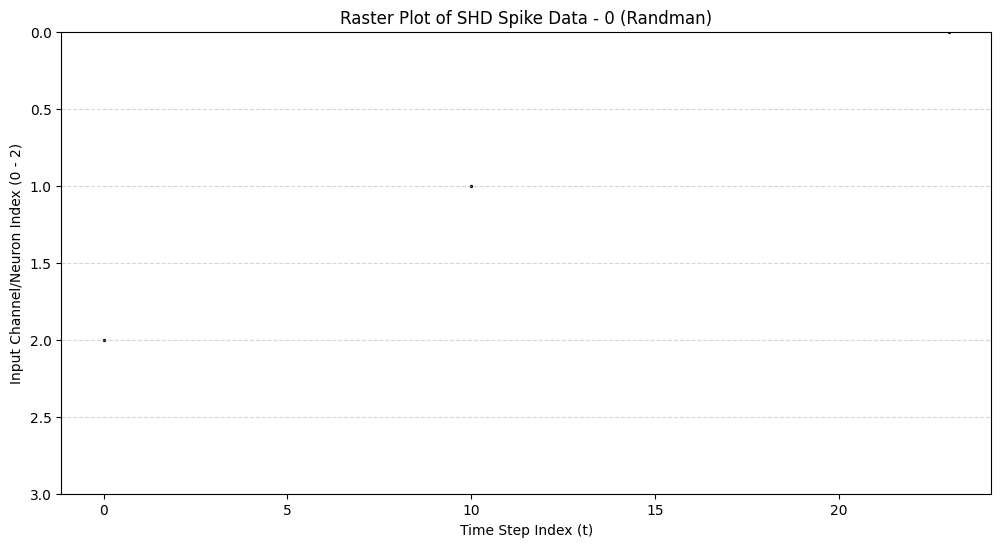

In [9]:
import numpy as np
for batch, batch_labels in test_loader:
    print(batch.shape)
    print(batch_labels.shape)
    break

# Visualize the first sample in the batch as spike raster plot
import matplotlib.pyplot as plt

NUM_CHANNELS = batch.shape[2]  # Should be 700 for SHD

data_array = batch[0].cpu().numpy()
spike_times, spike_channels = np.where(data_array > 0)

# --- 3. Create the Raster Plot ---
plt.figure(figsize=(12, 6))

# Use plt.scatter or plt.plot with markers for a classic raster plot
plt.scatter(
    spike_times,         # X-axis: Time (row index)
    spike_channels,      # Y-axis: Neuron/Channel (column index)
    s=2,                 # Marker size (adjust for visibility)
    color='black'
)

plt.xlabel("Time Step Index (t)")
plt.ylabel(f"Input Channel/Neuron Index (0 - {NUM_CHANNELS-1})")
plt.title(f"Raster Plot of SHD Spike Data - {batch_labels[0].item()} (Randman)")
plt.ylim(0, NUM_CHANNELS) # Set Y-axis to cover all channels
plt.grid(True, axis='y', alpha=0.5, linestyle='--')
plt.gca().invert_yaxis() # Often done for raster plots to match the matrix view

plt.show()

torch.Size([400, 50, 3])
torch.Size([400])


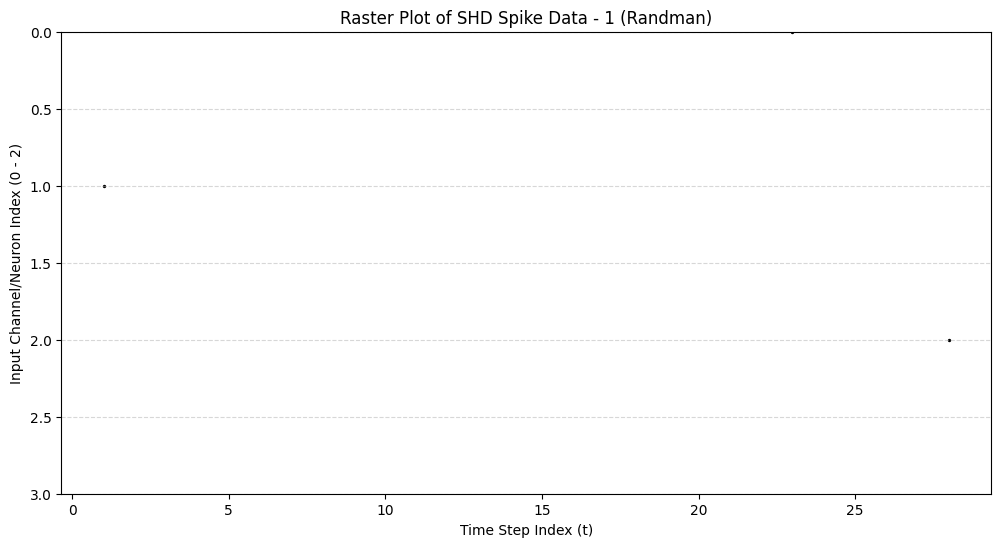

In [10]:
import numpy as np
for batch, batch_labels in test_loader:
    print(batch.shape)
    print(batch_labels.shape)
    break

# Visualize the first sample in the batch as spike raster plot
import matplotlib.pyplot as plt

NUM_CHANNELS = batch.shape[2]  # Should be 700 for SHD

idx = 1
data_array = batch[idx].cpu().numpy()
spike_times, spike_channels = np.where(data_array > 0)

# --- 3. Create the Raster Plot ---
plt.figure(figsize=(12, 6))

# Use plt.scatter or plt.plot with markers for a classic raster plot
plt.scatter(
    spike_times,         # X-axis: Time (row index)
    spike_channels,      # Y-axis: Neuron/Channel (column index)
    s=2,                 # Marker size (adjust for visibility)
    color='black'
)

plt.xlabel("Time Step Index (t)")
plt.ylabel(f"Input Channel/Neuron Index (0 - {NUM_CHANNELS-1})")
plt.title(f"Raster Plot of SHD Spike Data - {batch_labels[idx].item()} (Randman)")
plt.ylim(0, NUM_CHANNELS) # Set Y-axis to cover all channels
plt.grid(True, axis='y', alpha=0.5, linestyle='--')
plt.gca().invert_yaxis() # Often done for raster plots to match the matrix view

plt.show()

In [11]:
# Get training data for a model visualization!

In [13]:
from loss_landscapes.utils import get_shd_train_data

train_dataloader = get_shd_train_data()

choose data params for shd
encoding dim: 700, sensor size: (700, 1, 1)
Encoding dimension 700 matches the product of sensor size 700. No downsampling needed.
Cropping time to 1 seconds (1000000.0 microseconds).
data already downloaded: True
[tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.int16), tensor([11])]
encoding dim: 700, sensor size: (700, 1, 1)
Encoding dimension 700 matches the product of sensor size 700. No downsampling needed.
Cropping time to 1 seconds (1000000.0 microseconds).
data already downloaded: True
[tensor([[[0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.int16), tensor([10])]
Train class distributio

In [15]:
# Now load one of our best models!
from class_based_implementation.train_model import objective, MODEL_CLASSES, LOSS_FUNCTIONS # Import mappings too


model_name = 'Hybrid_NSN_SNN_V1_same_layer'
path = '/vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_5/grid_sampler/256_hidden/1.0_pct_data/0.5_percent_snn/reset_nsn_False/best_model_of_study.ckpt'
model_class = MODEL_CLASSES[model_name]
print(f"Loading model from {path}")
model = model_class.load_from_checkpoint(path, strict=False)


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Loading model from /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_5/grid_sampler/256_hidden/1.0_pct_data/0.5_percent_snn/reset_nsn_False/best_model_of_study.ckpt


In [17]:
# Take the model and visualize its output for the first training data sampel
for batch, batch_labels in train_dataloader:
    print(batch.shape)
    print(batch_labels.shape)
    break

sample_data = batch[0:1]  # Take the first sample in the batch
sample_label = batch_labels[0:1]

torch.Size([256, 500, 700])
torch.Size([256])


/tmp/ipykernel_3255425/2187483965.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


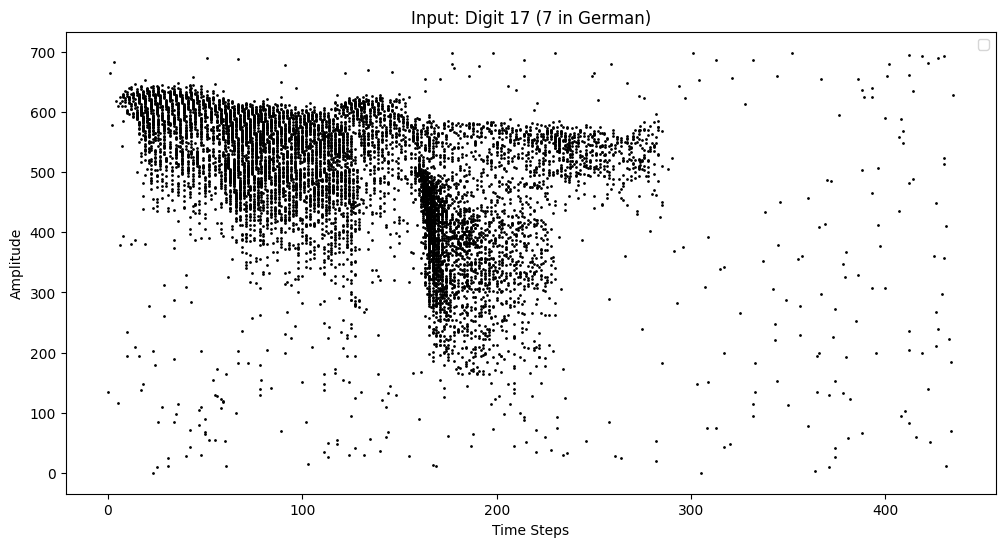

In [40]:
# Visualize the sample_data with another raster plot
import numpy as np
import matplotlib.pyplot as plt

# Create a raster plot
NUM_CHANNELS = sample_data.shape[2]  # Should be 700 for SHD
plt.figure(figsize=(12, 6))
# Use a scatter plot for raster visualization
data_array = sample_data[0].cpu().numpy()
spike_times, spike_channels = np.where(data_array > 0)
# Change color to black for plot
plt.scatter(spike_times, spike_channels, s=1, color='black')
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.title("Input: Digit 17 (7 in German)")
plt.legend()

In [34]:
sample_label

tensor([17])

In [20]:
# Find location of sample data (cuda or cpu)
import torch


device = 'cuda' if torch.cuda.is_available() else 'cpu'
sample_data = sample_data.to(device)

In [21]:
device

'cuda'

In [25]:
# Now use the model to get outputs for this sample
import torch

model.eval()  # Set model to evaluation mode
model = model.to(device)
with torch.no_grad():
    predictions, auxiliary_outputs, x, hidden_out_tensor = model(sample_data)
    print(f"Model output shape: {predictions.shape}")
    print(f"Model output: {predictions}")

Model output shape: torch.Size([1, 501, 20])
Model output: tensor([[[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         ...,
         [-11.2953,  -2.7028, -10.0989,  ...,  -6.7867,   1.4469,  -1.5000],
         [-11.2787,  -2.6849, -10.0760,  ...,  -6.7619,   1.4304,  -1.5132],
         [-11.2062,  -2.7186, -10.0229,  ...,  -6.7446,   1.4402,  -1.4343]]],
       device='cuda:0')


In [32]:
# Get rid of dimension sizes of 1
outputs = predictions.squeeze()
outputs.shape

torch.Size([501, 20])

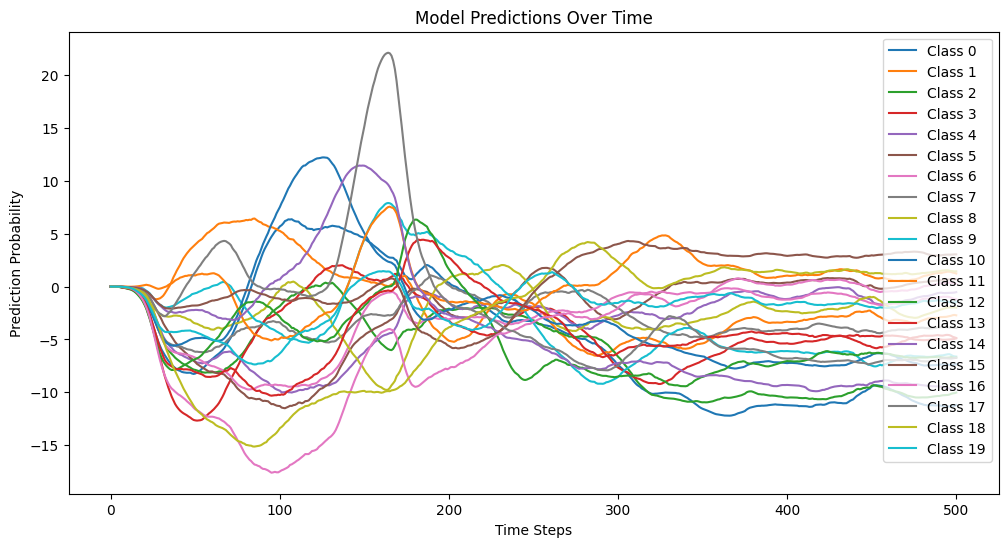

In [33]:
# Visualize this prediction output over time
import matplotlib.pyplot as plt


# Assuming predictions is a 2D tensor with shape (time_steps, num_classes)
time_steps = outputs.shape[0]
plt.figure(figsize=(12, 6))
for i in range(outputs.shape[1]):
    plt.plot(range(time_steps), outputs[:, i].cpu().numpy(), label=f"Class {i}")
plt.xlabel("Time Steps")
plt.ylabel("Prediction Probability")
plt.title("Model Predictions Over Time")
plt.legend()
plt.show()

In [ ]:
def visualize_model_predictions_over_time(predictions):
    import matplotlib.pyplot as plt
    outputs = predictions.squeeze()
    time_steps = outputs.shape[0]
    plt.figure(figsize=(12, 6))
    for i in range(outputs.shape[1]):
        plt.plot(range(time_steps), outputs[:, i].cpu().numpy(), label=f"Class {i}")
    plt.xlabel("Time Steps")
    plt.ylabel("Prediction Probability")
    plt.title("Model Predictions Over Time")
    plt.legend()
    plt.show()

def visualize_model(model_name, model_path, sample_data):
    import torch

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    sample_data = sample_data.to(device)

    # Load model class
    from class_based_implementation.train_model import MODEL_CLASSES
    model_class = MODEL_CLASSES[model_name]
    model = model_class.load_from_checkpoint(model_path, strict=False)

    model.eval()  # Set model to evaluation mode
    model = model.to(device)
    with torch.no_grad():
        predictions, _, _, _ = model(sample_data)
        print(f"Model output shape: {predictions.shape}")
        print(f"Model output: {predictions}")

    visualize_model_predictions_over_time(predictions)

(tensor([[[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
          [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
          [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
          ...,
          [-11.2953,  -2.7028, -10.0989,  ...,  -6.7867,   1.4469,  -1.5000],
          [-11.2787,  -2.6849, -10.0760,  ...,  -6.7619,   1.4304,  -1.5132],
          [-11.2062,  -2.7186, -10.0229,  ...,  -6.7446,   1.4402,  -1.4343]]],
        device='cuda:0'),
 {'spikes': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 1., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
  'ann_activations': tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+0